<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/banana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:


import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import log_banana
import samplers
importlib.reload(samplers)
from samplers import box_muller

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt



Cloning into 'MCMC-MonteCarlo-TFG'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 246 (delta 57), reused 4 (delta 4), pack-reused 145 (from 1)
Receiving objects: 100% (246/246), 5.02 MiB | 21.31 MiB/s, done.
Resolving deltas: 100% (118/118), done.


In [17]:
d = 2
num_iterations = 20000
t0 = 500
sd = (2.38**2) / d
epsilon = 1e-5

seed_box = 1
seed_unif = 2

Z_samples = box_muller(D=d, num_samples=num_iterations, seed=seed_box)

rng_unif = np.random.default_rng(seed_unif)
U_samples = rng_unif.random(num_iterations)

samples = np.zeros((num_iterations, d))
samples[0] = np.array([0.0, 0.0])

cov_t = np.eye(d) * 0.1
cov_empirical = np.zeros((d, d))
mean_t = samples[0].copy()

accepted = 0

for t in range(1, num_iterations):
    x_prev = samples[t-1]

    if t > t0:
        diff = x_prev - mean_t
        mean_t = mean_t + diff / t
        cov_empirical = ((t - 1) / t) * cov_empirical + (1 / t) * np.outer(diff, x_prev - mean_t)
        cov_t = sd * cov_empirical + sd * epsilon * np.eye(d)

    L = np.linalg.cholesky(cov_t)
    y_cand = x_prev + L @ Z_samples[t]

    log_alpha = log_banana(y_cand) - log_banana(x_prev)

    if np.log(U_samples[t]) < log_alpha:
        samples[t] = y_cand
        accepted += 1
    else:
        samples[t] = x_prev

print(f"Tasa de aceptacion AM: {accepted / num_iterations:.4f}")

Tasa de aceptacion AM: 0.1477


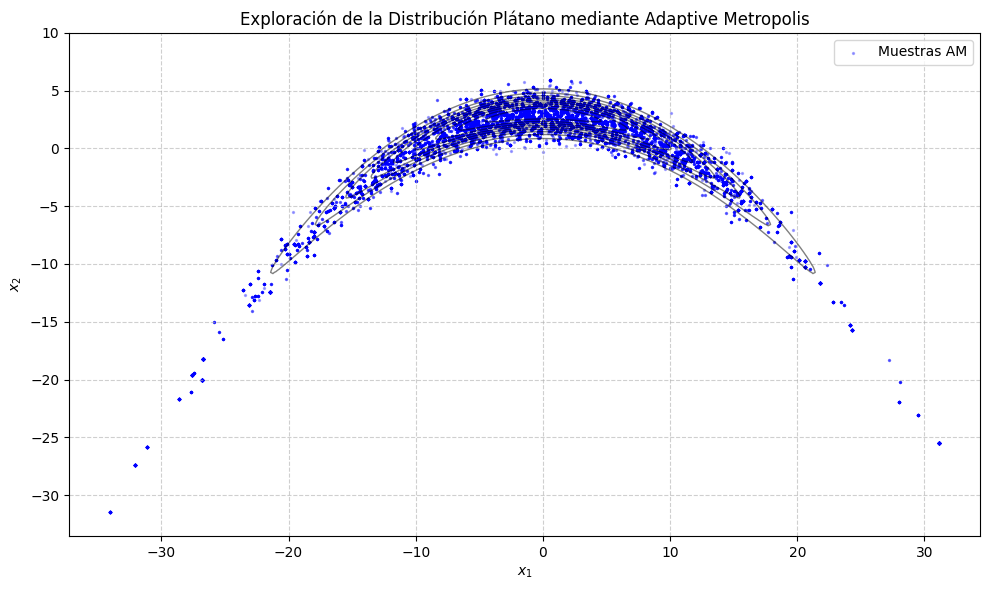

In [18]:
burn_in = 1000
valid_samples = samples[burn_in:]

x_grid = np.linspace(-25, 25, 200)
y_grid = np.linspace(-15, 10, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = np.exp(log_banana([X[i, j], Y[i, j]])) # Densidad real

plt.figure(figsize=(10, 6))

plt.contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)

plt.scatter(valid_samples[:, 0], valid_samples[:, 1], s=2, alpha=0.3, color='blue', label='Muestras AM')

plt.title('Exploración de la Distribución Plátano mediante Adaptive Metropolis')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('adaptive_metropolis_banana.png')
plt.show()